In [82]:
import pprint as pp
from typing import Any

import torch
import torch.nn as nn
# from torchvision import models
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from captum.attr import visualization as viz

# import onnxruntime as ort
import onnx
from onnx2pytorch import ConvertModel

# from tensorflow import keras
# import keras
import os

from wcwidth import width

os.sys.path.append(os.path.dirname(os.path.abspath('.')))

from util import model_utils
from util.attribution_methods import saliencyMethods as attr
from util.attribution_methods import GIGBuilder as GIG_Builder
from util.attribution_methods import AGI as AGI

# autoreload any external modules
# so that any changes are picked up
%load_ext autoreload
%autoreload 2

# configuration
attribution_methods_to_include = {
    "integrated_gradients" : "ig",
    "layer_wise_integrated_gradients" : "lig",
    "integrated_decision_gradients" : "idg",
    "generalized_integrated_gradients" : "gig",
    # "adversarial_gradient_integration" : "agi",
 }

# model = models.resnet101(weights = "ResNet101_Weights.IMAGENET1K_V2")
# model = model.eval()
# model.to("cuda:0")

# load keras/tensorflow ultrasound gesture classifier model here
keras_model_filepath: str = "/Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/cnn_perp_subject_4_200_epochs_224px_20260804_124025.keras"

onnx_model_filepath = "/Users/rickgladwin/Code/u_of_hull/dissertation/Acoustic_Gesture_Recognition_v2/results/models/cnn/onnx/cnn_perp_subject_4_200_epochs_224px_20260804_124025.onnx"

# Import onnx model and convert to a PyTorch model that can be used with torchvision code
print(f"Loading model from: onnx_model_filepath\nand converting to PyTorch...")
onnx_model = onnx.load(onnx_model_filepath)
# model = ConvertModel(onnx_model, export_input=True, export_output=True)
# convert onnx model to pytorch model
model = ConvertModel(onnx_model)
# Set the model in evaluation mode (prevents dropout during inference if applicable)
model.eval()

# Get ONNX prediction
# print(f"Loading model from: {onnx_model_filepath}...")
# ort_sess = ort.InferenceSession(onnx_model_filepath)
# onnx_input_name = ort_sess.get_inputs()[0].name


# onnx_pred = ort_sess.run(None, {"input_tensor": dummy_input})[0]
# onnx_pred = ort_sess.run(None, {"input_tensor": test_image})[0]

learning_rate = 1e-5
input_shape = (224, 224, 1)
num_classes = 12

# print(f"Loading model from: {ultrasound_model_filepath}...")
# model = keras.models.load_model(ultrasound_model_filepath, compile=False)
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
#     loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
# )

# standard image resize dimension for ResNet
img_hw = 224

# transforms for IG, LIG, and IDG
transform = transforms.Compose([
     transforms.Resize((img_hw, img_hw)),
     transforms.CenterCrop(img_hw),
     transforms.ToTensor()
])

# standard ImageNet normalization for IG, LIG, and IDG
transform_normalize = transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
)

# transforms and normalization for GIG and AGI
resize = transforms.Resize((img_hw, img_hw))
crop = transforms.CenterCrop(img_hw)
# use this version to normalize an image with three channels (RGB)
normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
# use this version to normalize an image with one channel (grayscale)
normalize_single_channel = transforms.Normalize(0.485, 0.229)
# normalize ultrasound images for the onnx loaded model
to_tensor = transforms.ToTensor()

# color map for Captum attribution visualization
default_cmap = LinearSegmentedColormap.from_list('custom blue',  [
    (0, '#ffffff'), (0.25, '#0000ff'), (1, '#0000ff')
], N = 256)  

# TODO: address this warning:
# /Users/rickgladwin/Code/u_of_hull/dissertation/Integrated-Decision-Gradients/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
# import pynvml  # type: ignore[import]
# /Users/rickgladwin/Code/u_of_hull/dissertation/Integrated-Decision-Gradients/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
# from .autonotebook import tqdm as notebook_tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading model from: onnx_model_filepath
and converting to PyTorch...


<h1>Load an image and get the class</h1>

In [83]:
import tensorflow as tf

if False:
    # copied from Acoustic_Gesture_Recognition_v2.ultrasound_gesture_cnn_classification.py
    def load_subject_arrays(root: str, mode: str, subject: str, image_size: int):
        """
        Loads and preprocesses ultrasound data for training and testing. This function handles loading of data
        from disk, ensures data consistency, resizes images, normalizes the data, and returns the processed
        datasets along with the number of classes. It is specifically used for preparing ultrasound images for
        machine learning tasks, such as classification or segmentation.
    
        Parameters:
        root: str
            The root directory containing the dataset.
        mode: str
            The mode of data capture, one of ["mirror", "perp"], depending on the orientation of the ultrasound probe.
        subject: str
            Identifier of the subject whose data is to be loaded, one of ["Subject_1", "Subject_2", "Subject_3", "Subject_4", "Subject_5", "Subject_6"].
        image_size: int
            Desired width and height for image resizing. The function assumes a square dimension.
    
        Returns:
        tuple
            A tuple consisting of:
            - (x_train, y_train): Processed training dataset (features, labels).
            - (x_test, y_test): Processed testing dataset (features, labels).
            - num_classes: The total number of unique gesture classes in the dataset (12, for the 2025 mirror/perp dataset).
        """
    
        # example folder path to data:
        # /home/username/ultrasound_gesture_data/mirror/Subject_1/
        d = os.path.join(root, mode, subject)
        x_train = np.load(os.path.join(d, "X_m_train.npy"))
        x_test  = np.load(os.path.join(d, "X_m_test.npy"))
        y_train: np.ndarray = np.load(os.path.join(d, "y_m_train.npy"))
        y_test: np.ndarray  = np.load(os.path.join(d, "y_m_test.npy"))
    
        y_train = y_train.astype(np.int64).ravel()
        y_test  = y_test.astype(np.int64).ravel()
    
        # Ensure channel dim (N, H, W, 1)
        if x_train.ndim == 3: x_train = x_train[..., np.newaxis]
        if x_test.ndim  == 3: x_test  = x_test[..., np.newaxis]
    
        # Resize to image_size (keeps your ViT/CNN parity if you want 320)
        # TODO: look at converting to tensors that can be used with MPS optimization
        x_train = tf.image.resize(tf.convert_to_tensor(x_train), (image_size, image_size)).numpy()
        x_test  = tf.image.resize(tf.convert_to_tensor(x_test ), (image_size, image_size)).numpy()
    
        # Normalize to [0,1]
        if x_train.dtype != np.float32:
            x_train = x_train.astype("float32"); x_test = x_test.astype("float32")
        maxv = max(float(x_train.max()), 1.0)
        x_train /= maxv; x_test /= maxv
    
        class_count = int(max(y_train.max(), y_test.max()) + 1)
        return (x_train, y_train), (x_test, y_test), class_count


Image shape: torch.Size([1, 224, 224])
Image dtype: torch.float32
Image max: 0.9921568632125854
Unsqueezed input_img shape: torch.Size([1, 1, 224, 224])
Unsqueezed input_img dtype: torch.float32
Unsqueezed input_img max: 0.9921568632125854
Unsqueezed input_img min: 0.0
CUDA available:  False
MPS available:   True
Device name:     mps
target_class for example image img/ultrasound_subject_4_gesture_0_x_test_0_example.png: 0
name for target_class 0: IndFlex
model_utils.getPrediction() for image and target_class 0: IndFlex:
88.8433 IndFlex


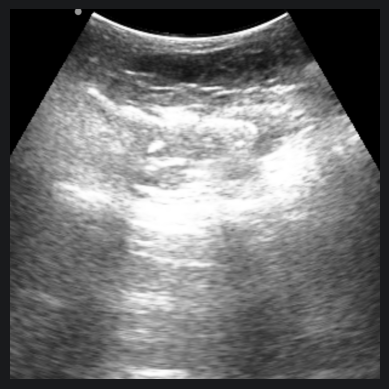

In [93]:
from PIL.ImageFile import ImageFile

# TODO: import example images from each gesture class
# TODO: get the class for each image
# image_path = "img/jet.jpg"
# img = Image.open(image_path)

# image_path = "img/ultrasound_subject_4_gesture_0_example.png"
image_path = "img/ultrasound_subject_4_gesture_0_x_test_0_example.png"
# image_path = "img/ultrasound_subject_4_gesture_1_x_test_0_example.png"
# image_path = "img/ultrasound_subject_4_gesture_1_x_test_10_example.png"
# image_path = "img/ultrasound_subject_4_gesture_2_x_test_10_example.png"
# image_path = "img/ultrasound_subject_4_gesture_2_x_test_30_example.png"
# image_path = "img/ultrasound_subject_4_gesture_3_x_test_30_example.png"
# image_path = "img/ultrasound_subject_4_gesture_3_x_test_38_example.png"
# image_path = "img/ultrasound_subject_4_gesture_3_x_test_47_example.png"
# image_path = "img/ultrasound_subject_4_gesture_3_x_test_70_example.png"
img: ImageFile = Image.open(image_path, formats=["PNG"])

trans_img = transform(img)
print(f"Image shape: {trans_img.shape}")
print(f"Image dtype: {trans_img.dtype}")
print(f"Image max: {trans_img.max()}")

# single sample shapes in PyTorch are torch.Size([channels, height, width])
# input_img = normalize(trans_img)
image_channels = trans_img.shape[0] # 1 for grayscale, 3 for RGB

# input_img = normalize_single_channel(trans_img)
# NOTE: transform(img) already includes transforms.ToTensor()
# input_img = to_tensor(trans_img)
# print(f"Normalized shape: {input_img.shape}")
# print(f"Normalized image max: {input_img.max()}")
# print(f"Normalized image dtype: {input_img.dtype}")
# input_img = input_img.unsqueeze(0)
input_img = trans_img.unsqueeze(0)
print(f"Unsqueezed input_img shape: {input_img.shape}")
print(f"Unsqueezed input_img dtype: {input_img.dtype}")
print(f"Unsqueezed input_img max: {input_img.max()}")
print(f"Unsqueezed input_img min: {input_img.min()}")
# example unsqueezed shape: torch.Size([1, 1, 224, 224])
# PyTorch uses NCHW format, so this represents torch.Size([batch, channels, height, width])

# check available devices
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"MPS available:   {torch.backends.mps.is_available()}")
print(f"Device name:     {'mps' if torch.backends.mps.is_available() else 'cpu'}")

# device = "cuda:0"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# override device to cpu
# device = "cpu"

# configure the model for the device
model.to(device)

# TODO: check model.to(device) and tensor = tensor.to(device)

# copied from tensorflow_image_classifier_explainability/integrated_gradients_ultrasound.ipynb
# gesture class index (0-11) and class shortnames
gesture_class_index_and_shortnames: list[tuple[int, str]] = [
    (0, "IndFlex"),
    (1, "MidFlex"),
    (2, "RinFlex"),
    (3, "PinFlex"),
    (4, "IndPinch"),
    (5, "IndMidPinch"),
    (6, "IndMidRinPinch"),
    (7, "AllPinch"),
    (8, "MidRinPinch"),
    (9, "Fist"),
    (10, "Hook"),
    (11, "Open"),
]

classes = [shortname for _, shortname in gesture_class_index_and_shortnames]

target_class = model_utils.getClass(input_img, model, device)
print(f"target_class for example image {image_path}: {target_class}")
# open the class list so the detected class string can be returned for printing
# with open('../util/class_maps/ImageNet/imagenet_classes.txt') as f:
#     classes = [line.strip() for line in f.readlines()]
name = classes[target_class]
print(f"name for target_class {target_class}: {name}")
print(f"model_utils.getPrediction() for image and target_class {target_class}: {name}:")
print(model_utils.getPrediction(input_img, model, device, target_class)[0] * 100, name)

plt.axis("off")

# use gray colormap for grayscale (single channel) images
if image_channels == 1:
    img_colormap = plt.get_cmap('gray')
else:
    img_colormap = None

plt.imshow(img, cmap=img_colormap)
plt.show()

## Find the best example image for each class
We will be building an attribution map for each gesture, using an example image from that gesture.
We want to use a sample image that results in a high-confidence prediction, in order to ensure (as much as possible)
that the attribution map will be useful.

In [100]:
# For each target gesture class:
# for each image whose true class matches the target gesture class, use the model to generate prediction scores for all classes.
# From the correct predictions, select the one with the narrowest spread (highest confidence)
# Use the image related to this prediction as the example image for this gesture class.

test_class_for_max_confidence: int = 4

# load y_test
# get the indices for y_test values that match the target class
# load the x_test images that match those indices

test_subject_id: str = "4"
test_mode: str = "perp"
# y_filename: str = "y_m_test.npy"
y_filename: str = "y_m_train.npy"
# X_filename: str = "X_m_test.npy"
X_filename: str = "X_m_train.npy"
ultrasound_data_folder_path: str = f"/Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/{test_mode}/Subject_{test_subject_id}/"
gesture_class_filepath: str = os.path.join(ultrasound_data_folder_path, y_filename)
ultrasound_data_filepath: str = os.path.join(ultrasound_data_folder_path, X_filename)

# get class indices
y_classes_loaded: np.ndarray  = np.load(gesture_class_filepath)
y_classes_loaded: np.ndarray = y_classes_loaded.astype(np.int64).ravel()

# import and normalize image tensors
x_images_loaded = np.load(ultrasound_data_filepath)
print(f"x_images_loaded.dtype: {x_images_loaded.dtype}")
# Ensure channel dim (N, H, W, 1)
if x_images_loaded.ndim  == 3: x_images_loaded  = x_images_loaded[..., np.newaxis]

x_images_loaded = tf.image.resize(tf.convert_to_tensor(x_images_loaded), (img_hw, img_hw)).numpy()
print(f"x_images_loaded.dtype: {x_images_loaded.dtype}")

# Normalize to [0,1]
if x_images_loaded.dtype != np.float32:
    x_images_loaded = x_images_loaded.astype("float32")
maxv = max(float(x_images_loaded.max()), 1.0)
x_images_loaded /= maxv
print(f"type of x_images_loaded.dtype: {type(x_images_loaded)}")


def get_predictions_for_class_images(gesture_class: int, y_classes: np.ndarray, x_images: np.ndarray) -> dict[int, float]:
    print(f"### getting indices for class: {gesture_class} {classes[gesture_class]}")
    # print(f"y_classes[:10]: {y_classes[:10]}")
    y_indices_for_target_class: list[int] = []
    for i in range(0, len(y_classes)):
        if y_classes[i] == gesture_class:
            y_indices_for_target_class.append(i)

    print(f"y_indices_for_target_class {gesture_class}: {y_indices_for_target_class[:10]}...{y_indices_for_target_class[-10:]}")

    x_probabilities: dict[int, float] = {}

    # # get images at the matching class indices
    # x_test = np.load(ultrasound_data_filepath)
    # # Ensure channel dim (N, H, W, 1)
    # if x_test.ndim  == 3: x_test  = x_test[..., np.newaxis]
    # 
    # x_test  = tf.image.resize(tf.convert_to_tensor(x_test ), (img_hw, img_hw)).numpy()
    # 
    # # Normalize to [0,1]
    # if x_test.dtype != np.float32:
    #     x_train = x_test.astype("float32"); x_test = x_test.astype("float32")
    # maxv = max(float(x_test.max()), 1.0)
    # x_test /= maxv

    for y_class_index in y_indices_for_target_class:
        # test prediction
        x_test_image = x_images[int(y_class_index)]
        
        # convert to tensor
        # and put the tensor on the device (mps), same as the model
        x_test_image_tensor = torch.tensor(x_test_image).to(device)
        model.to(device)
        # x_test_image_tensor = torch.tensor(x_test_image).to('cpu')
        # model.to('cpu')
        
        x_test_logits = model(x_test_image_tensor)
        # print(f"x_test_logits.shape: {x_test_logits.shape}")
        # print(f"\nx_test_logits: {x_test_logits}")
        
        x_test_logits_cpu = x_test_logits.cpu()
        x_softmax = tf.nn.softmax(x_test_logits_cpu.detach().numpy())
        # print(f"\nx_softmax: {x_softmax}")
        # print(f"x_softmax.shape: {x_softmax.shape}")
        # print(f"x_softmax[0]: {x_softmax[0]}")
        # print(f"x_softmax[0][0]: {x_softmax[0][0]}")
        
        x_softmax_for_class = x_softmax[0][int(gesture_class)]
        # print(f"x_softmax_for_class: {x_softmax_for_class}")
    
        x_probabilities[y_class_index] = x_softmax_for_class
    
    return x_probabilities
    
# for y_class_index in y_indices_for_target_class:
# highest_probability_with_index: tuple = (0, 0)
# for key in x_probabilities.keys():
#     print(f"x_probabilities[{key}]: {x_probabilities[key]}")
#     if x_probabilities[key] > highest_probability_with_index[1]:
#         highest_probability_with_index = (key, x_probabilities[key])
# 
# print(f"{test_class_for_max_confidence} {classes[test_class_for_max_confidence]} highest_probability_with_index: {highest_probability_with_index}")


highest_probability_and_index_by_class: list[dict[str, int|float]] = []
for class_id in [x[0] for x in gesture_class_index_and_shortnames]:
# for class_id in range(3):
    x_class_probabilities = get_predictions_for_class_images(class_id, y_classes_loaded, x_images_loaded)
    # pp.pprint(f"x_class_probabilities: {x_class_probabilities}")
    highest_probability_with_index: tuple = (0, 0)
    print_count: int = 0
    for key in x_class_probabilities.keys():
        print(f"x_class_probabilities[{key}]: {x_class_probabilities[key]}") if print_count < 5 else None
        print(f"...") if print_count == 10 else None
        if x_class_probabilities[key] > highest_probability_with_index[1]:
            highest_probability_with_index = (key, x_class_probabilities[key])
        print_count += 1
    # highest_probability_with_index_for_class: dict[str, int|float] = get_predictions_for_class_images(class_id, y_classes, x_images)
    # highest_probability_and_index_by_class.append(highest_probability_with_index_for_class)
    highest_probability_and_index_by_class.append({'class_id': class_id, 'image_index': highest_probability_with_index[0], 'image_class_probability': highest_probability_with_index[1]})

# print(f"highest_probability_and_index_by_class: {highest_probability_and_index_by_class}")

print(f"----------------------------------------------")
print(f"class_id, image_index, image_class_probability")
for element in highest_probability_and_index_by_class:
    print(f"{element['class_id']}, {element['image_index']}, {element['image_class_probability']}")
print(f"----------------------------------------------")

# yields:
# ----------------------------------------------
# class_id, image_index, image_class_probability
# 0,  2471, 0.9963749051094055
# 1,  3738, 0.9974944591522217
# 2,  3809, 0.9975920915603638
# 3,  1580, 0.9517228603363037
# 4,  2857, 0.9985976815223694
# 5,  2934, 0.9980654120445251
# 6,  635,  0.997138261795044
# 7,  712,  0.9733940958976746
# 8,  3248, 0.9923747181892395
# 9,  923,  0.9704126715660095
# 10, 1054, 0.9922754168510437
# 11, 3531, 0.9981940388679504
# ----------------------------------------------

# for each image:
# - convert it to a format the model can use
# - generate its class prediction scores
# - if the highest score is for the wrong class, continue
# - calculate the (crossentropy?) in the predictions
# - save the values and image id

# find the prediction with maximum confidence (lowest spread?)
# use that image


x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
### getting indices for class: 0 IndFlex
y_indices_for_target_class 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...[3690, 3691, 3692, 3693, 3694, 3695, 3696, 3697, 3698, 3699]
x_class_probabilities[0]: 0.985322117805481
x_class_probabilities[1]: 0.985322117805481
x_class_probabilities[2]: 0.9322991967201233
x_class_probabilities[3]: 0.9322991967201233
x_class_probabilities[4]: 0.9322991967201233
...
### getting indices for class: 1 MidFlex
y_indices_for_target_class 1: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]...[3790, 3791, 3792, 3793, 3794, 3795, 3796, 3797, 3798, 3799]
x_class_probabilities[100]: 0.003868319559842348
x_class_probabilities[101]: 0.9883795976638794
x_class_probabilities[102]: 0.9883795976638794
x_class_probabilities[103]: 0.9762856960296631
x_class_probabilities[104]: 0.9762856960296631
...
### getting indices for class: 2 RinFlex
y_indices_for_target_class

## Save the best-fit images
Given the list of images and indices where each image is the highest confidence match for its class, fetch and save these images

x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
image 200:
x_images_loaded[0].shape: (224, 224, 1)
x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
image 2471:
x_images_loaded[0].shape: (224, 224, 1)
x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
image 3738:
x_images_loaded[0].shape: (224, 224, 1)
x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
image 3809:
x_images_loaded[0].shape: (224, 224, 1)
x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
image 1580:
x_images_loaded[0].shape: (224, 224, 1)
x_images_loaded.dtype: uint8
x_images_loaded.dtype: float32
type of x_images_loaded.dtype: <class 'numpy.ndarray'>
image 2857:
x_images_loaded[0].shape: (224, 224, 1)

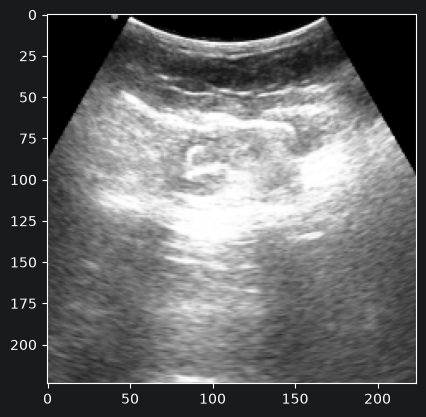

In [112]:

from pathlib import Path


def fetch_and_save_example_image(class_id: int, data_root: str, subject_id: int, image_id: int, mode: str="perp", ) -> None:
    # y_filename: str = "y_m_test.npy"
    y_filename: str = "y_m_train.npy"
    # X_filename: str = "X_m_test.npy"
    X_filename: str = "X_m_train.npy"
    ultrasound_data_folder_path: str = os.path.join(data_root, mode, f"Subject_{subject_id}")
    gesture_class_filepath: str = os.path.join(ultrasound_data_folder_path, y_filename)
    ultrasound_data_filepath: str = os.path.join(ultrasound_data_folder_path, X_filename)
    
    # get class indices
    y_classes_loaded: np.ndarray  = np.load(gesture_class_filepath)
    y_classes_loaded: np.ndarray = y_classes_loaded.astype(np.int64).ravel()
    
    # import and normalize image tensors
    x_images_loaded = np.load(ultrasound_data_filepath)
    
    if x_images_loaded.shape[-1] == 1:
        x_img_cmap = "gray"
    else:
        x_img_cmap = None
    
    save_img_folder_path: str = "img/class_exemplars/"
    save_img_filename: str = f"ultrasound_exemplar_class_{class_id}_subject_{subject_id}_{mode}_image_{image_id}.png"
    save_img_filepath: str = os.path.join(save_img_folder_path, save_img_filename)
    
    # ensure filepath exists
    Path(save_img_folder_path).mkdir(parents=True, exist_ok=True)
    
    print(f"x_images_loaded.dtype: {x_images_loaded.dtype}")
    # Ensure channel dim (N, H, W, 1)
    if x_images_loaded.ndim  == 3: x_images_loaded  = x_images_loaded[..., np.newaxis]
    
    x_images_loaded = tf.image.resize(tf.convert_to_tensor(x_images_loaded), (img_hw, img_hw)).numpy()
    print(f"x_images_loaded.dtype: {x_images_loaded.dtype}")
    
    # Normalize to [0,1]
    if x_images_loaded.dtype != np.float32:
        x_images_loaded = x_images_loaded.astype("float32")
    maxv = max(float(x_images_loaded.max()), 1.0)
    x_images_loaded /= maxv
    print(f"type of x_images_loaded.dtype: {type(x_images_loaded)}")
    
    print(f"image {image_id}:")
    plt.imshow(x_images_loaded[0], cmap=x_img_cmap)
    reshaped_image = x_images_loaded[0].squeeze(-1)
    plt.imsave(save_img_filepath, reshaped_image, cmap=x_img_cmap)

    print(f"x_images_loaded[0].shape: {x_images_loaded[0].shape}")
    # expanded_img = x_images_loaded[0]

ultrasound_data_root: str = "/Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/"
target_subject_id: int = 4
target_mode: str = "perp"
target_class_id: int = 5

fetch_and_save_example_image(
    class_id=target_class_id,
    data_root=ultrasound_data_root,
    subject_id=target_subject_id,
    mode=target_mode,
    image_id=200,
)

for element in highest_probability_and_index_by_class:
    example_class: int = element['class_id']
    example_image_id: int = element['image_index']
    fetch_and_save_example_image(
        class_id=example_class,
        data_root=ultrasound_data_root,
        subject_id=target_subject_id,
        mode=target_mode,
        image_id=example_image_id,
    )

    
    


<h1>Generate attributions</h1>

In [86]:
steps = 50
batch_size = 25
# TODO: change the naming here, or change how the default parameters are declared.
#  The type of the `baseline` variable changes from int to a pytorch tensor.
baseline = 0 # this will result in a black baseline by default

Gradients for ultrasound image classifiers work better with a custom baseline rather than a black baseline, since 
a) black has a specific meaning in an ultrasound image within the beam (regions of low density), and 
b) there are regions in the image that are outside the representation of the "beam" that are black and carry a different meaning (a lack of information).

We will use a custom baseline that is the average of all ultrasound images in the dataset that are not of the target class.

In [87]:
# build "out of class average baseline" for ultrasound class 0

# load ultrasound image data
# modified version of loading code from Claude Code (2026)
import numpy as np

train_image_source_file = "/Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/X_m_train.npy"
print(f"loading image data from {train_image_source_file}")
train_image_data = np.load(train_image_source_file)

print(f"train_image_data.shape: {train_image_data.shape}")

# ensure 4D SHAPE (batch, height, width, channels) before resizing
if train_image_data.ndim == 3:
    print(f"expanding dims...")
    train_image_data = np.expand_dims(train_image_data, axis=-1)

# excerpt from Gemini 3 Flash (2026a)
# Process in batches to prevent tensorflow-metal memory failure
BATCH_SIZE = 500
resized_batches = []

print(f"Resizing {len(train_image_data)} images in batches...")
for steps_option in range(0, len(train_image_data), BATCH_SIZE):
    batch = train_image_data[steps_option: steps_option + BATCH_SIZE]

    # Convert and resize a smaller chunk
    res = tf.image.resize(
        tf.constant(batch, dtype=tf.float32),
        size=(240, 240),
        preserve_aspect_ratio=True,
        method="bilinear",
    )
    res = tf.image.resize_with_pad(res, target_height=224, target_width=224)

    # Optional: Normalize to [0, 1] while still in float
    if tf.reduce_max(res) > 1.0:
        res = res / 255.0

    resized_batches.append(res)
    print(f"Processed up to {steps_option + len(batch)}")

# Combine everything back into one tensor
train_image_tensor = tf.concat(resized_batches, axis=0)
print(f"Final train_image_tensor.shape: {train_image_tensor.shape}")

# -- end memory-safe code

# get a tensor with the class labels
class_source_file = "/Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/y_m_train.npy"
print(f"loading class data from {class_source_file}")
class_data = np.load(class_source_file)

print(f"class_data.shape:   {class_data.shape}")

loading image data from /Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/X_m_train.npy
train_image_data.shape: (4800, 640, 640, 1)
Resizing 4800 images in batches...
Processed up to 500
Processed up to 1000
Processed up to 1500
Processed up to 2000
Processed up to 2500
Processed up to 3000
Processed up to 3500
Processed up to 4000
Processed up to 4500
Processed up to 4800
Final train_image_tensor.shape: (4800, 224, 224, 1)
loading class data from /Users/rickgladwin/Code/u_of_hull/dissertation/bimbraw_2025_dataset/data/perp/Subject_4/y_m_train.npy
class_data.shape:   (4800,)


Next we will remove all images from the training set that belong to the target class.

In [88]:
# compute the test class index from the test class name
# get the index in the class vocabulary corresponding to the target class name
test_class = name # e.g. "IndPinch"

target_model_class_index: int = -1
for key, value in gesture_class_index_and_shortnames:
    print(f"key: {key}, value: {value}")
    if value == test_class: # e.g. "IndPinch"
        target_model_class_index = key
        break

if target_model_class_index == -1:
    raise ValueError(f"Could not find target class {test_class} in gesture_class_index_and_shortnames")


# get just the out-of-class images
print(f"test_class:               {test_class}")               # e.g. "IndPinch"
print(f"target_model_class_index: {target_model_class_index}") # e.g. 4

print(f"all image count: {train_image_tensor.shape[0]}")
print(f"getting just the out-of-class images...")
out_of_class_indices = np.where(class_data != target_model_class_index)[0]
out_of_class_indices = tf.convert_to_tensor(out_of_class_indices)
print(f"out_of_class_indices.shape: {out_of_class_indices.shape}")
print(f"out_of_class_indices.dtype: {out_of_class_indices.dtype}")

out_of_class_images = tf.gather(train_image_tensor, out_of_class_indices)
out_of_class_labels = tf.gather(class_data, out_of_class_indices)

print(f"out_of_class_images.shape: {out_of_class_images.shape}")
print(f"out_of_class_labels.shape: {out_of_class_labels.shape}")

key: 0, value: IndFlex
test_class:               IndFlex
target_model_class_index: 0
all image count: 4800
getting just the out-of-class images...
out_of_class_indices.shape: (4400,)
out_of_class_indices.dtype: <dtype: 'int64'>
out_of_class_images.shape: (4400, 224, 224, 1)
out_of_class_labels.shape: (4400,)


Now we can average the out-of-class images to produce a baseline image.

avg_out_of_class_image:


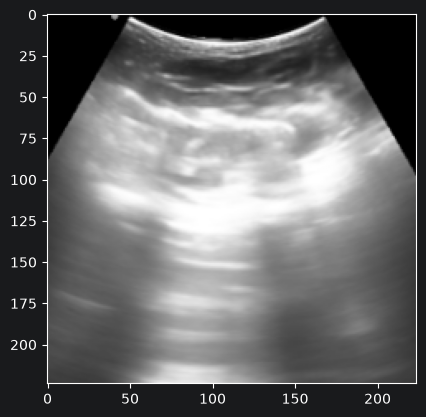

In [89]:
# average the out-of-class images
# -- excerpt from Gemini 3 Flash (2026b)

# Use TensorFlow's native mean function on the tensor
avg_out_of_class_image = tf.math.reduce_mean(out_of_class_images, axis=0)
print(f"avg_out_of_class_image:")
# To visualize it with plt.imshow, convert to numpy and squeeze
plt.imshow(np.squeeze(avg_out_of_class_image.numpy()), cmap='gray')
plt.show()

# -- end excerpt



In [90]:
call_model_args: dict[str, Any] = {'class_idx_str': target_class.item()}
guided_ig = GIG_Builder.GuidedIG()

# shape of input_img used for the gradient calculation
# the baseline shape must match this shape
print(f"input_img.shape: {input_img.shape}")

# baseline = torch.zeros_like(input_img)
# print(f"baseline.shape: {baseline.shape}")
baseline_black = torch.zeros_like(input_img)
print(f"baseline_black.shape: {baseline_black.shape}")

baseline_numpy = avg_out_of_class_image.numpy()
print(f"ultrasound baseline_numpy.shape: {baseline_numpy.shape}")
# permute and unsqueeze to go from (H, W, C) to (N, C, H, W)
baseline_tensor = torch.from_numpy(baseline_numpy)
baseline_tensor = baseline_tensor.permute(2, 0, 1)
print(f"baseline_tensor.shape: {baseline_tensor.shape}")
baseline = baseline_tensor.unsqueeze(0)
print(f"baseline.shape: {baseline.shape}")

# TODO: ** get baseline working

gig = guided_ig.GetMask(input_img, model, device, GIG_Builder.call_model_function, call_model_args, x_baseline=baseline, x_steps=50, max_dist=1.0, fraction=0.5)

input_img.shape: torch.Size([1, 1, 224, 224])
baseline_black.shape: torch.Size([1, 1, 224, 224])
ultrasound baseline_numpy.shape: (224, 224, 1)
baseline_tensor.shape: torch.Size([1, 224, 224])
baseline.shape: torch.Size([1, 1, 224, 224])


RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

Build the attributions for IG, LIG, and IDG

In [ ]:
# alpha star = 1, plain IG attribution
ig = attr.IG(input=input_img, model=model, steps=steps, batch_size=batch_size, alpha_star=1, baseline=baseline, device=device, target_class=target_class)

In [ ]:
# alpha star = 0.9, Left IG attribution
# TODO: check that the integration approximation is as expected
#  (trapezoidal) and that the other parameters like alpha_star, batch_size, etc. match the other repo.
# lig = attr.IG(input_img, model, steps, batch_size, .9, 0, device, target_class)
lig = attr.IG(input=input_img, model=model, steps=steps, batch_size=batch_size, alpha_star=.9, baseline=baseline, device=device, target_class=target_class)

In [ ]:
# get integrated decision gradients attribution
# idg = attr.IDG(input_img, model, steps, batch_size, 0, device, target_class)
idg = attr.IDG(input=input_img, model=model, steps=steps, batch_size=batch_size, baseline=baseline, device=device, target_class=target_class)

In [ ]:
if "adversarial_gradient_integration" in attribution_methods_to_include:
    epsilon = 0.05
    topk = 1
    max_iter = 20
    agi_img = AGI.LoadImage(image_path, resize, crop)
    agi_img = agi_img.astype(np.float32)
    
    # cast image tensor to device
    agi_img = torch.from_numpy(agi_img)
    # agi_img = torch.from_numpy(agi_img).to(device)
    # agi_img = torch.from_numpy(agi_img).to("cpu")
    
    # 1. Ensure format is (Channels, Height, Width)
    # If LoadImage returns (H, W, C), we permute to (C, H, W)
    if agi_img.shape[-1] == 1 or agi_img.shape[-1] == 3:
        agi_img = agi_img.permute(2, 0, 1)
    
    # 2. Add the Batch dimension (1, C, H, W)
    agi_img = agi_img.unsqueeze(0)
    
    # 3. Handle Single Channel vs 3 Channels
    # If your model expects 3 channels (like ResNet) but your data is 1 channel:
    if agi_img.shape[1] == 1:
        agi_img = agi_img.repeat(1, 3, 1, 1) # Copy the 1 channel into 3 channels
    
    if False and image_channels == 1:
        mean = [0.485]
        std = [0.229]
    else:
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
    norm_layer = AGI.Normalize(mean, std)
    modified_model = nn.Sequential(norm_layer, model).to(device)        
    selected_ids = range(0, 999, int(1000 / topk))
    
    # TODO: this raises "ValueError: axes don't match array"
    _, _, agi = AGI.test(modified_model, device, agi_img, epsilon, topk, selected_ids, max_iter)
    
    # perform AGI thresholding 
    percentile = 80
    upperbound = 99
    hm = agi
    hm = np.mean(hm, axis=0)
    q = np.percentile(hm, percentile)
    u = np.percentile(hm, upperbound)
    hm[hm<q] = q
    hm[hm>u] = u
    hm = (hm-q)/(u-q)
    
    # AGI attribution
    agi = np.reshape(hm, (img_hw, img_hw, 1))

<h1>Visualize the attributions </h1>

In [ ]:
# transform the [C, H, W] image and attributions to [H, W, C] for display

def normalize_min_max(tensor: torch.Tensor) -> torch.Tensor:
    t_min = tensor.min()
    t_max = tensor.max()
    print(f"t_min, t_max: {t_min}, {t_max}")
    return (tensor - t_min) / (t_max - t_min)

print(f"trans_img.shape: {trans_img.shape}") # e.g. trans_img.shape: torch.Size([1, 224, 224])
print(f"trans_img.max: {trans_img.max()}")

# convert a grayscale image to RGB
# (captum expects an RGB image and has no option to display a grayscale image)
if trans_img.shape[0] == 1:
    trans_img = trans_img.repeat(3, 1, 1)

# TODO: make sure the .cpu() call makes sense here if using another device
# img_print = np.transpose(trans_img.squeeze().detach().cpu().numpy(), (1, 2, 0))
img_print = np.transpose(trans_img.detach().cpu().numpy(), (1, 2, 0))
# ig_print = np.transpose(ig.squeeze().detach().cpu().numpy(), (1,2,0))
print(f"ig.shape: {ig.shape}")
print(f"ig.max: {ig.max()}")
ig_chw = ig.unsqueeze(0)
# ig_print = np.transpose(ig.detach().cpu().numpy(), (1, 2, 0))
ig_print = np.transpose(ig_chw.detach().cpu().numpy(), (1, 2, 0))
# lig_print = np.transpose(lig.squeeze().detach().cpu().numpy(), (1,2,0))
print(f"lig.shape: {lig.shape}")
print(f"lig.max: {lig.max()}")
lig_chw = lig.unsqueeze(0)
lig_print = np.transpose(lig_chw.detach().cpu().numpy(), (1, 2, 0))
# idg_print = np.transpose(idg.squeeze().detach().cpu().numpy(), (1,2,0))
print(f"idg.shape: {idg.shape}")
print(f"idg.min, idg.max: {idg.min()}, {idg.max()}")
# idg = normalize_min_max(idg)
# print(f"normalized idg.min, idg.max: {idg.min()}, {idg.max()}")
# idg = to_tensor(idg)
idg_chw = idg.unsqueeze(0)
idg_print = np.transpose(idg_chw.detach().cpu().numpy(), (1, 2, 0))
# gig_print = np.transpose(gig.squeeze().detach().cpu().numpy(), (1, 2, 0))
print(f"gig.shape: {gig.shape}")
print(f"gig.max: {gig.max()}")
gig_chw = gig.squeeze(0)
gig_print = np.transpose(gig_chw.detach().cpu().numpy(), (1, 2, 0))
if "adversarial_gradient_integration" in attribution_methods_to_include:
    agi_print = agi

# use 0 to 100 luminosity colormap
default_cmap = plt.get_cmap("inferno")

print(f"baseline.shape: {baseline.shape}")
print(f"img_print.shape: {img_print.shape}")

class_title_suffix: str = f"class {target_class} {test_class}"

# plt.imshow(img_print)
plt.imshow(baseline_numpy, cmap=plt.get_cmap("gray"))
plt.title(f"Baseline: OOCA {class_title_suffix}")
# plt.title(f"Baseline: black")
plt.axis('off')
plt.show()

# TODO: make a loop that creates a grid of multiple classes and IG techniques

# baseline image
# fig, _ = viz.visualize_image_attr(baseline_numpy,
#                                   baseline_numpy,
#                                   method="original_image",
#                                   title="Baseline",
#                                   cmap="gray",
#                                   plt_fig_axis = plt.subplots(1, 1))

# class sample image
# fig, _ = viz.visualize_image_attr(None,
# fig, _ = viz.visualize_image_attr(img_print,
#                             img_print,
#                             method="original_image",
#                             title=f"Input: {target_class} {test_class}",
#                             # cmap=plt.get_cmap("gray"),
#                             plt_fig_axis = plt.subplots(1, 1))

fig, ax = viz.visualize_image_attr(img_print,
                                  img_print,
                                  method="original_image",
                                  title=f"Input: {class_title_suffix}",
                                  # cmap=plt.get_cmap("gray"),
                                  plt_fig_axis = plt.subplots(1, 1))

fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
fig.suptitle("test title")
ax.set_title("HERE")
ax.set_axis_off()
ax.margins(0)
ax.xaxis.set_major_locator(plt.NullLocator())
ax.yaxis.set_major_locator(plt.NullLocator())

# 4. Optional: If saving, use these flags to prevent the border from returning
# plt.savefig("output.png", bbox_inches='tight', pad_inches=0)

plt.show()
plt.close()


# ig_print_min = tf.reduce_min(ig_print)
# ig_print_max = tf.reduce_max(ig_print)
# print(f"ig_print_min:      {ig_print_min}, ig_print_max:      {ig_print_max}")
# ig_print_norm = (ig_print - ig_print_min) / (ig_print_max - ig_print_min + 1e-8)
# print(f"ig_print_norm_min: {tf.reduce_min(ig_print_norm)}, ig_print_norm_max: {tf.reduce_max(ig_print_norm)}")
# 
# print(f"non-normalized IG:")
# plt.imshow(ig_print, cmap=plt.get_cmap("inferno"))
# plt.show()
# 
# print(f"normalized IG:")
# plt.imshow(ig_print_norm, cmap=plt.get_cmap("inferno"))
# plt.show()
# 
# # plot overlay
# fig2, ax2 = plt.subplots(1, 1)
# ax2.imshow(img_print, cmap=plt.get_cmap("gray"))
# ax2.imshow(ig_print_norm, alpha=0.4, cmap=plt.get_cmap("inferno"))
# ax2.axis('off')
# plt.tight_layout()
# plt.show()
# 

heatmap_overlay_alpha: float = 0.75
# TEST

## manual option 1

if False:
    # Ensure data is on CPU and in correct shape for manual plotting
    # img_print should be (H, W, 3), ig_print should be (H, W, 1)
    bg_img = img_print.copy()
    if bg_img.max() > 1.0:
        bg_img /= 255.0
    
    ## np.array normalization
    
    # # Pre-calculate the attribution overlay to ensure it has data
    # attr_2d = np.abs(ig_print.squeeze())
    # # Check if it's all zeros
    # print(f"DEBUG: attr_2d max: {attr_2d.max()}, min: {attr_2d.min()}")
    # 
    # # Robust normalization
    # denom = attr_2d.max() - attr_2d.min()
    # if denom > 0:
    #     attr_norm = (attr_2d - attr_2d.min()) / denom
    # else:
    #     attr_norm = attr_2d
    
    ## end np.array normalization


    ## pytorch normalization

    # Ensure we are working with a clean NumPy array of floats
    attr_2d = np.abs(ig_print.squeeze())
    attr_2d = np.array(attr_2d, dtype=np.float64) # Force to 64-bit float

    # Calculate min and max explicitly
    a_min = np.min(attr_2d)
    a_max = np.max(attr_2d)
    denom = a_max - a_min

    print(f"type(attr_2d): {type(attr_2d)}")
    print(f"type(denom): {type(denom)}")

    # Print these to verify the inputs to the division
    print(f"DEBUG: a_min={a_min}, a_max={a_max}, denom={denom}")

    # Perform normalization
    if denom > 1e-9:
        attr_norm = (attr_2d - a_min) / denom
    else:
        attr_norm = np.zeros_like(attr_2d)

    print(f"attr_norm.min(): {np.min(attr_norm)}, max: {np.max(attr_norm)}")

    ## end pytorch normalization
        
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # --- AX 2 FIRST (Manual) ---
    # We do this first because Captum's call might trigger a flush/show
    ax2.imshow(bg_img)
    # ax2.imshow(attr_norm, cmap=default_cmap, alpha=heatmap_overlay_alpha)
    ax2.imshow(attr_norm, cmap=default_cmap, vmin=0, vmax=1)
    # ax2.imshow(attr_norm, cmap=default_cmap, alpha=0.5)
    ax2.set_title("Manual Overlay")
    ax2.axis('off')

## end manual option 1

## manual option 2
if False:
    # np.array normalization 
    
    # attr_2d = np.abs(ig_print.squeeze())
    # denom = attr_2d.max() - attr_2d.min()
    # attr_norm = (attr_2d - attr_2d.min()) / (denom + 1e-7)
    # 
    # print(f"attr_norm.min(): {attr_norm.min()}, max: {attr_norm.max()}")
    
    ## end np.array normalization
    
    ## pytorch normalization

    # Ensure we are working with a clean NumPy array of floats
    attr_2d = np.abs(ig_print.squeeze())
    attr_2d = np.array(attr_2d, dtype=np.float64) # Force to 64-bit float
    
    # Calculate min and max explicitly
    a_min = np.min(attr_2d)
    a_max = np.max(attr_2d)
    denom = a_max - a_min
    
    # Print these to verify the inputs to the division
    print(f"DEBUG: a_min={a_min}, a_max={a_max}, denom={denom}")
    
    # Perform normalization
    if denom > 1e-9:
        attr_norm = (attr_2d - a_min) / denom
    else:
        attr_norm = np.zeros_like(attr_2d)
    
    print(f"attr_norm.min(): {np.min(attr_norm)}, max: {np.max(attr_norm)}")
    
    ## end pytorch normalization
    
    # 1. Map the normalized attribution to your colormap
    # This turns the (H, W) array into an (H, W, 4) RGBA array based on the colormap
    # Note: we use 'default_cmap' which you defined as inferno or similar
    rgba_heatmap = default_cmap(attr_norm)
    
    # 2. Apply the dynamic alpha
    # We replace the constant alpha channel (index 3) with our normalized attribution
    # You can multiply it by heatmap_overlay_alpha to control the overall maximum intensity
    rgba_heatmap[..., 3] = attr_norm * heatmap_overlay_alpha
    # rgba_heatmap[..., 3] = attr_norm / heatmap_overlay_alpha
    
    # 3. Plotting
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot the background (original image)
    # ax2.imshow(bg_img)
    ax2.imshow(bg_img, alpha=0.25)
    
    # Plot the dynamic RGBA heatmap
    # Since it's already RGBA, imshow will use the internal alpha channel automatically
    ax2.imshow(rgba_heatmap)
    
    ax2.set_title("Dynamic Alpha Overlay")
    ax2.axis('off')

## end manual option 2

## manual option 3
# with clipping
if False:
    # 1. Get magnitude
    attr_2d = np.abs(ig_print.squeeze())
    
    # 2. Robust Scaling: Clip outliers at the 99th percentile
    # This ensures that the bulk of the 'important' pixels are bright
    v_max = np.percentile(attr_2d, 99.9)
    v_min = attr_2d.min()
    
    # Clip values to the [min, v_max] range
    attr_clipped = np.clip(attr_2d, v_min, v_max)
    
    # 3. Normalize the clipped values
    denom = v_max - v_min
    if denom > 1e-9:
        attr_norm = (attr_clipped - v_min) / denom
    else:
        attr_norm = np.zeros_like(attr_2d)
    
    # apply gamma correction to brighten middle values
    # Squaring or taking the root can shift the luminosity
    attr_norm = np.power(attr_norm, 0.8) # 0.8 makes middle-range values brighter
    
    # 4. Create RGBA heatmap
    rgba_heatmap = default_cmap(attr_norm)
    rgba_heatmap[..., 3] = attr_norm * heatmap_overlay_alpha

    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # 5. Plot
    ax2.imshow(bg_img, alpha=0.20)
    ax2.imshow(rgba_heatmap)
    
    # TODO: look into viz.visualize_image_attr() to see what normalization and
    #  gamma correction it's doing, and replicate that
    
    # TODO: ** build an algorithm that, for each gesture and a given subject, generates predictions
    #  for every image in that gesture's true image set, and indicates the image for which the model
    #  had the most certainty (narrowest probability distribution) for that gesture.
    #  Use that image as the basis for building the attribution maps that will be used to make the
    #  attention masks.


## end manual option 3

# --- AX 1 SECOND (Captum) ---
viz.visualize_image_attr(ig_print,
                         img_print,
                         method='heat_map',
                         title="Captum Heatmap",
                         cmap=default_cmap,
                         sign='absolute_value',
                         show_colorbar=False,
                         plt_fig_axis=(fig1, ax1))

plt.show()


# end TEST

# fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# fig, _ = viz.visualize_image_attr(ig_print,
fig, _ = viz.visualize_image_attr(ig_print,
                                  img_print,
                                  method='heat_map',
                                  # method='blended_heat_map',
                                  title=f"IG: {class_title_suffix}",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  show_colorbar=False,
                                  plt_fig_axis = plt.subplots(1, 1))
                                  # plt_fig_axis = (fig1, ax1))

# fig, ax2 = viz.visualize_image_attr(ig_print,
_ = viz.visualize_image_attr(ig_print,
                            img_print,
                            # method='heat_map',
                            method='blended_heat_map',
                            title=f"IG: {class_title_suffix} Overlay",
                            cmap=default_cmap,
                            alpha_overlay=heatmap_overlay_alpha,
                            sign='absolute_value',
                            show_colorbar=False,
                            plt_fig_axis = plt.subplots(1, 1))
                            # plt_fig_axis = (fig1, ax2))

# plt.tight_layout()
# plt.show()
# plt.close()




fig, _ = viz.visualize_image_attr(idg_print,
                            img_print,
                            method='heat_map',
                            title=f"IDG: {class_title_suffix}",
                            cmap=default_cmap,
                            sign='absolute_value',
                                  show_colorbar=True,
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(idg_print,
                                  img_print,
                                  # method='heat_map',
                                  method='blended_heat_map',
                                  title=f"IDG: {class_title_suffix} Overlay",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  alpha_overlay=heatmap_overlay_alpha,
                                  show_colorbar=True,
                                  plt_fig_axis = plt.subplots(1, 1))


fig, _ = viz.visualize_image_attr(lig_print,
                            img_print,
                            method='heat_map',
                            title=f"LIG: {class_title_suffix}",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(lig_print,
                                  img_print,
                                  method='blended_heat_map',
                                  title=f"LIG: {class_title_suffix} Overlay",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  alpha_overlay=heatmap_overlay_alpha,
                                  plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(gig_print,
                            img_print,
                            method='heat_map',
                            title=f"GIG: {class_title_suffix}",
                            cmap=default_cmap,
                            sign='absolute_value',
                            plt_fig_axis = plt.subplots(1, 1))

fig, _ = viz.visualize_image_attr(gig_print,
                                  img_print,
                                  method='blended_heat_map',
                                  title=f"GIG: {class_title_suffix} Overlay",
                                  cmap=default_cmap,
                                  sign='absolute_value',
                                  alpha_overlay=heatmap_overlay_alpha,
                                  plt_fig_axis = plt.subplots(1, 1))

if "adversarial_gradient_integration" in attribution_methods_to_include:
    fig, _ = viz.visualize_image_attr(agi_print,
                                img_print,
                                method='heat_map',
                                title=f"AGI: {class_title_suffix}",
                                cmap=default_cmap,
                                sign='absolute_value',
                                plt_fig_axis = plt.subplots(1, 1))


In [ ]:
import cv2

# TODO: put a 10x10 grid over the heatmap plot
# TODO: crate a 10x10 attention map for the patches in the ViT from
#  the (average? weighted average? normalized sum? other?) attribution scores
#  in each patch

# patch size: 224 / 10 = 22.4
# NOTE: (img_size // patch_size), i.e. patches per dimension, should match the value used when training
# the ViT model to which the attention map will be applied.
# e.g. if the ViT uses a 320px image and a patch size of 32 (10 patches per dimension),
# a 224px image here should have a patch size of 14.
# 224px in the ViT model (from 2026-08-10) with patch size 14 --> 16 patches per dimension
img_size: int = idg.shape[1] # 224
patches_per_dimension: int = 16 # match the ViT model
patch_size: int = img_size // patches_per_dimension
# patch_size: int = 14

patch_lines: list[int] = [round(patch_size * x) for x in range(patches_per_dimension + 1)]
print(f"patch_lines: {patch_lines}")

print(f"idg.shape: {idg.shape}")
print(f"idg.dtype: {idg.dtype}")
print(f"idg.max(): {idg.max()}")
print(f"idg.min(): {idg.min()}")
idg_cpu = idg.cpu()
idg_numpy = idg_cpu.detach().numpy().astype(np.float32)
# print(f"idg_numpy: {idg_numpy}")

print(f"np.abs(idg).max(): {np.abs(idg_numpy).max()}")
print(f"tf.reduce_max(idg): {tf.reduce_max(idg_numpy)}")
print(f"tf.reduce_min(idg): {tf.reduce_min(idg_numpy)}")

# use absolute attribution scores for attention
idg_abs = np.abs(idg_numpy)
idg_abs = idg_abs.astype(np.float32)
print(f"idg_abs.dtype: {idg_abs.dtype}")
print(f"Data Min: {idg_abs.min()}, Max: {idg_abs.max()}")
print(f"tf.reduce_max(idg): {tf.reduce_max(idg_abs)}")
print(f"tf.reduce_min(idg): {tf.reduce_min(idg_abs)}")

# coarse_attribution will be a 10x10 array of floats, each representing a function
# of the attribution values in the attribution map for each patch (10x10 patches).

coarse_attribution_sums = [[0.0] * patches_per_dimension for _ in range(patches_per_dimension)]

print(f"idg_abs:")
print(f"DEBUG: Actual Max value is {idg_abs.max()}")

# 1. Normalize the data so the highest attribution point is exactly 1.0
# Add a tiny epsilon to avoid division by zero if the whole map is 0
idg_norm = idg_abs / (idg_abs.max() + 1e-12)

# get the attribution scores for all pixels in each patch and sum them
for i in range(patches_per_dimension):
    for j in range(patches_per_dimension):
        # coarse_attribution.append(np.sum(idg_norm[i*10:(i+1)*10, i*10:(i+1)*10]))
        row_start: int = patch_lines[i]
        row_end: int = patch_lines[i + 1]
        col_start: int = patch_lines[j]
        col_end: int = patch_lines[j + 1]
        # print(f"fetching attribution scores from ({row_start}, {col_start}) to ({row_end}, {col_end})")
        idg_range = idg_norm[row_start:row_end, col_start:col_end]
        coarse_attribution_sums[i][j] = np.sum(idg_range)

# print(f"coarse_attribution:\n{coarse_attribution}")
coarse_attribution_sums_array = np.array(coarse_attribution_sums)

coarse_attribution_sums_max: float = np.max(coarse_attribution_sums_array)
coarse_attribution_sums_min: float = np.min(coarse_attribution_sums_array)
print(f"coarse_attribution_sums_max: {coarse_attribution_sums_max}")
print(f"coarse_attribution_sums_min: {coarse_attribution_sums_min}")

# normalize coarse_attribution
coarse_attribution_sums_normalized = coarse_attribution_sums_array / (coarse_attribution_sums_array.max() + 1e-12)

# resize and smooth to match image dimensions (for comparison
# with ViT-generated all-classes attention maps


# 2. Plot the normalized data
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# attribution map with patch gridlines
axs[0,0].imshow(idg_norm, cmap='inferno', vmin=0, vmax=1)
axs[0,0].set_title(f"Normalized IDG for {target_class} {test_class}")
axs[0,0].set_xticks(patch_lines, labels=patch_lines, rotation=90)
axs[0,0].set_yticks(patch_lines)
axs[0,0].set_xlabel("pixel x dimension")
axs[0,0].set_ylabel("pixel y dimension")
# draw patches on the attribution map
for line in patch_lines:
    axs[0,0].axvline(x=line, alpha=0.25, color='white', linewidth=0.5, linestyle='-')
    axs[0,0].axhline(y=line, alpha=0.25, color='white', linewidth=0.5, linestyle='-')

boundaries = np.arange(-0.5, patches_per_dimension, 1)

# coarse attribution sums with patch gridlines
axs[0,1].imshow(coarse_attribution_sums, cmap='inferno')
axs[0,1].set_title(f"Coarse Attribution Sums (CAS) for {target_class} {test_class}")
axs[0,1].set_xticks(boundaries)
axs[0,1].set_yticks(boundaries)
axs[0,1].grid(which='major', color='white', alpha=0.5, linestyle='-', linewidth=0.5)
axs[0,1].set_xticklabels([int(b + 0.5) for b in boundaries])
axs[0,1].set_yticklabels([int(b + 0.5) for b in boundaries])
axs[0,1].set_xlabel("patch column")
axs[0,1].set_ylabel("patch row")

axs[1,0].imshow(coarse_attribution_sums_array, cmap='inferno')
axs[1,0].set_title(f"CAS Normalized for {target_class} {test_class}")
axs[1,0].set_xticks(boundaries)
axs[1,0].set_yticks(boundaries)
axs[1,0].grid(which='major', color='white', alpha=0.5, linestyle='-', linewidth=0.5)
axs[1,0].set_xticklabels([int(b + 0.5) for b in boundaries])
axs[1,0].set_yticklabels([int(b + 0.5) for b in boundaries])
axs[1,0].set_xlabel("patch column")
axs[1,0].set_ylabel("patch row")


# from Acoustic_Gesture_Recognition_v2 repo
attention_heatmap = cv2.resize(coarse_attribution_sums_array, (img_size, img_size), interpolation=cv2.INTER_CUBIC)

# print(f"resized heatmap:")
# plt.title("resized heatmap")
# plt.imshow(attention_heatmap, cmap="inferno")
# plt.show()

# 7. Normalize heatmap values strictly between 0 and 1 for clean rendering
attention_heatmap_norm = (attention_heatmap - np.min(attention_heatmap)) / (np.max(attention_heatmap) - np.min(attention_heatmap) + 1e-8)

axs[1,1].imshow(attention_heatmap_norm, cmap="inferno")
axs[1,1].set_title(f"Attention Heatmap for {target_class} {test_class}")
# attribution map with patch gridlines
# axs[1,1].imshow(idg_norm, cmap='inferno', vmin=0, vmax=1)
# axs[1,1].set_title(f"Normalized IDG for {target_class} {test_class}")
axs[1,1].set_xticks(patch_lines, labels=patch_lines, rotation=90)
axs[1,1].set_yticks(patch_lines)
axs[1,1].set_xlabel("pixel x dimension")
axs[1,1].set_ylabel("pixel y dimension")
# draw patches on the attribution map
for line in patch_lines:
    axs[1,1].axvline(x=line, alpha=0.25, color='white', linewidth=0.5, linestyle='-')
    axs[1,1].axhline(y=line, alpha=0.25, color='white', linewidth=0.5, linestyle='-')

plt.show()

# TODO: discuss what spatial information the CNN contains. Classically, we think of CNNs as
#  not retaining the information about spatial relationships in the training images.
#  But if we use the CNN as part of a process of predicting the class output for the image,
#  we can recover some of the spatial information.
#  
#  Does the CNN _contain_ the spatial information? Not really, or not in the same way the
#  original image does. (** confirm this ﷿﷿﷿ if there are processes that will generate the
#  original images from classifier models, then can the model be said to contain the original
#  images' information? Or does the model only contain the information in a statistical sense?)
#  Does the DNA sequence contain all the information about the final animal it builds? No.
#  But the DNA sequence PLUS a set of rules about how chemicals and proteins and other molecules
#  interact IS enough to generate the final organism. This is algorithmic information theory.
#  The question about the CNN is similar. Look at the attribution map. The CNN itself only 
#  contained _localized_ information about the image. Patterns and shapes.
#  
#  But the information in the CNN PLUS the Integrated Gradients algorithm lets the CNN contribute
#  spatial information about the image. A caveat here: the IG algorithm requires the inclusion
#  of the image itself. So all the spatial information about a single image is available to 
#  the system when the algorithm runs. What the CNN provides is information about _all_ the images
#  in the test image's class, plus information about the images not in the test image's class,
#  plus information about the _relationships_ between those images and classes, that's not
#  available in any one image.
#  
#  So the CNN is storing information that can be used to retrieve some spatial information relevant
#  to a single image, but what the CNN actually stores is information at a different subjective
#  or statistical level. It contains information about the classes and relationships.
#  So when we run the IG algorithm alongside a CNN and an image, the information we're recovering
#  concerns how the image is related to the rest of the images and classes in the training dataset.

